Here we are analyzing the responses to the survey for potential control variables.
There are two responses, one by Family Medicine doctor and one from a Biostatistician. 
We use weighted average to get the average importance score, with the doctor having the wieght of 2 and 
the biostatistician having the wight of 1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/data/input/Potential Control Variables for Synthetic Doctor-Patient Dialog and Note Generation-Form 1.xlsx")
df.head()

,ID,Start time,Completion time,Email,Name,Last modified time,Name2,Professional Title2,How important is Demographic Information?,Age,...,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.15",How important is Diagnostic Overshadowing?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.16",How important is Chronic Stress?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.17",How important is Stigma?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.18",How important is Treatment Disparities?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.19","Please let us know any comments or feedback, including any variables that you think is important and missing, suggestions for merging variables, or any other feedback you see fit. Thank you."
0,2.0,2023-12-05 21:17:43,2023-12-05 21:27:13,anonymous,NaN,NaN,Christopher Meaney,Biostatistician,8.0,8,...,NaN,5.0,NaN,7.0,NaN,7,NaN,7.0,NaN,NaN
1,3.0,2023-12-10 16:51:42,2023-12-10 17:05:59,anonymous,NaN,NaN,Noah Crampton,Family physician,9.0,8,...,NaN,6.0,NaN,6.0,NaN,7,NaN,8.0,NaN,Physical exam? Investigation/Test results? Ref...
2,NaN,NaT,NaT,NaN,NaN,NaN,avegare_score,NaN,8.5,8,...,0.0,5.5,0.0,6.5,0.0,7,0.0,7.5,0.0,NaN


In [4]:
# just the third row as the average:
df_average = df.tail(1)
df_average

,ID,Start time,Completion time,Email,Name,Last modified time,Name2,Professional Title2,How important is Demographic Information?,Age,...,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.15",How important is Diagnostic Overshadowing?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.16",How important is Chronic Stress?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.17",How important is Stigma?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.18",How important is Treatment Disparities?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.19","Please let us know any comments or feedback, including any variables that you think is important and missing, suggestions for merging variables, or any other feedback you see fit. Thank you."
2,NaN,NaT,NaT,NaN,NaN,NaN,avegare_score,NaN,8.5,8,...,0.0,5.5,0.0,6.5,0.0,7,0.0,7.5,0.0,NaN


In [5]:
# droping the NaN:
df_average = df_average.dropna(axis='columns')
df_average

,Name2,How important is Demographic Information?,Age,Gender,Ethnicity,Socio-Economic Status,Education Level,Health Literacy,Job Status,How important is Medical History?,...,How important is Overburdened Staff?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.15",How important is Diagnostic Overshadowing?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.16",How important is Chronic Stress?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.17",How important is Stigma?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.18",How important is Treatment Disparities?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.19"
2,avegare_score,8.5,8,8,7.5,7.5,7.5,6,7,9.5,...,6,0.0,5.5,0.0,6.5,0.0,7,0.0,7.5,0.0


In [6]:
df_average.columns

Index(['Name2', 'How important is Demographic Information?', 'Age', 'Gender',
       'Ethnicity', 'Socio-Economic Status', 'Education Level',
       'Health Literacy', 'Job Status', 'How important is Medical History?',
       'Previous diagnoses\n', 'Family medical history\n',
       'Medication history\n', 'Allergies\n', 'Chronic conditions\n',
       'How important is Symptom Description?', 'Severity\n', 'Duration\n',
       'Associated Symptoms\n', 'Frequency\n', 'Impact on daily activities\n',
       'Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important and missing, or anything else.3',
       'How important is Clinical Setting?',
       'Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.',
       'How important is Geographical Location?', 'Big City vs Small City\n',
       'Rural vs Urban\n', 'Pollution and Environme

In [7]:
# just to focus on high-level variables for now, not sub variables:

df_average_subset = df_average[[col for col in df_average.columns if 'How important is' in col]]
df_average_subset.columns

Index(['How important is Demographic Information?',
       'How important is Medical History?',
       'How important is Symptom Description?',
       'How important is Clinical Setting?',
       'How important is Geographical Location?',
       'How important is Provider's Experience Level?',
       'How important is Type of Encounter?',
       'How important is Length of Dialogs and Notes?',
       'How important is Education Level of the Area?',
       'How important is Native or Non-native English-Speaking Patient?',
       'How important is Language?', 'How important is Medical Outcome?',
       'How important is Healthcare System?',
       'How important is Patient's Behavior?',
       'How important is Patient’s Self-Reported Habits and Lifestyle ?',
       'How important is Visited with Companion?',
       'How important is Patient's Recall?',
       'How important is Confirmation Bias?',
       'How important is Treatment Bias?',
       'How important is Socioeconomic Conditio

In [8]:
# cleaning the names:
df_average_subset.columns = [col.replace('How important is ', '').replace('?', '') for col in df_average_subset.columns]
df_average_subset.columns

Index(['Demographic Information', 'Medical History', 'Symptom Description',
       'Clinical Setting', 'Geographical Location',
       'Provider's Experience Level', 'Type of Encounter',
       'Length of Dialogs and Notes', 'Education Level of the Area',
       'Native or Non-native English-Speaking Patient', 'Language',
       'Medical Outcome', 'Healthcare System', 'Patient's Behavior',
       'Patient’s Self-Reported Habits and Lifestyle ',
       'Visited with Companion', 'Patient's Recall', 'Confirmation Bias',
       'Treatment Bias', 'Socioeconomic Condition of the Area',
       'Resource Limitation', 'Overburdened Staff', 'Diagnostic Overshadowing',
       'Chronic Stress', 'Stigma', 'Treatment Disparities'],
      dtype='object')

In [9]:
len(df_average_subset.columns)

26

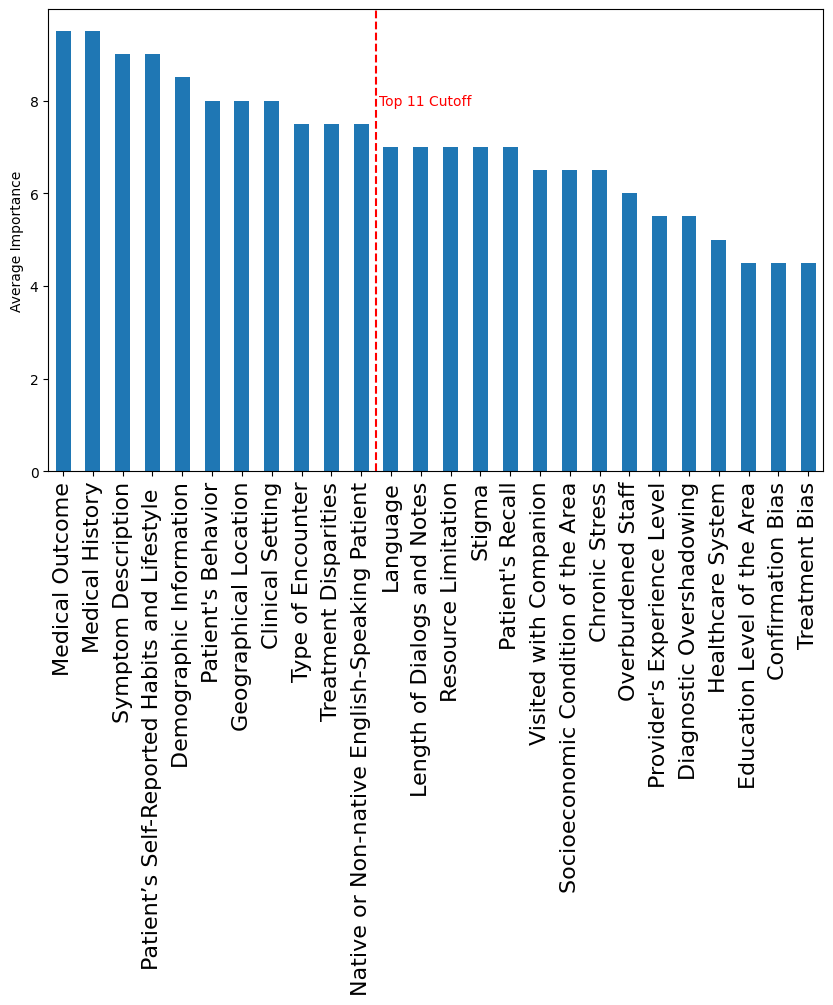

In [14]:
df_sorted = df_average_subset.T.sort_values(by=df_average_subset.index[0], ascending=False)

# Plotting the sorted values
ax = df_sorted.plot(kind='bar', legend=False, figsize=(10, 6))

# Adding titles and labels
#plt.title('Bar Graph of Variable Importance')
#plt.xlabel('Variable')
plt.ylabel('Average Importance')

plt.xticks(fontsize=16)

line_position = 10.5
plt.axvline(x=line_position, color='red', linestyle='--')

# Add text to the red line
plt.text(line_position + 0.1, plt.ylim()[1] * 0.8, 'Top 11 Cutoff', color='red', verticalalignment='center')


# Show the plot
plt.show()

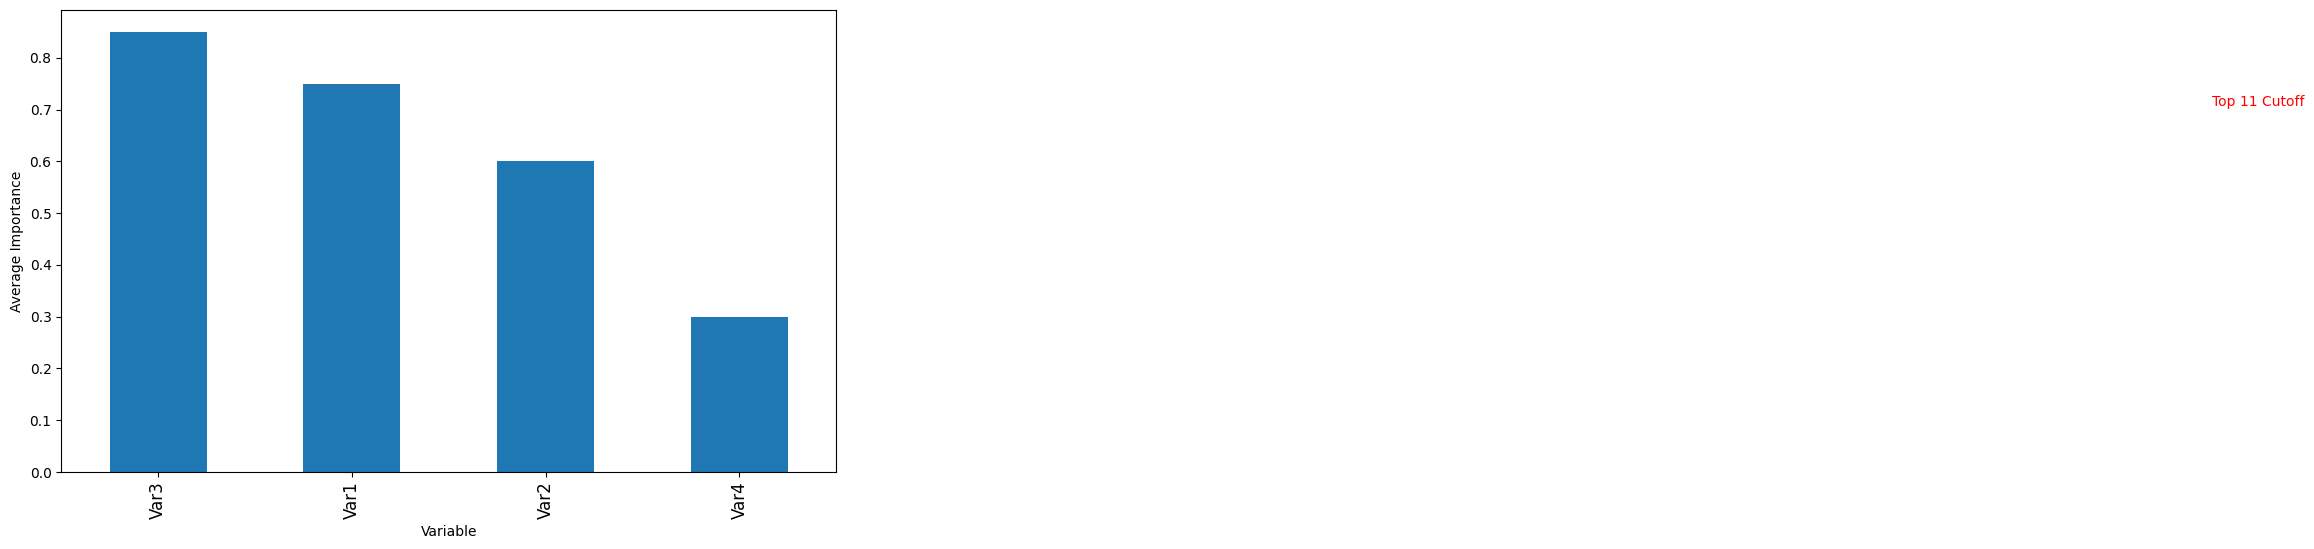

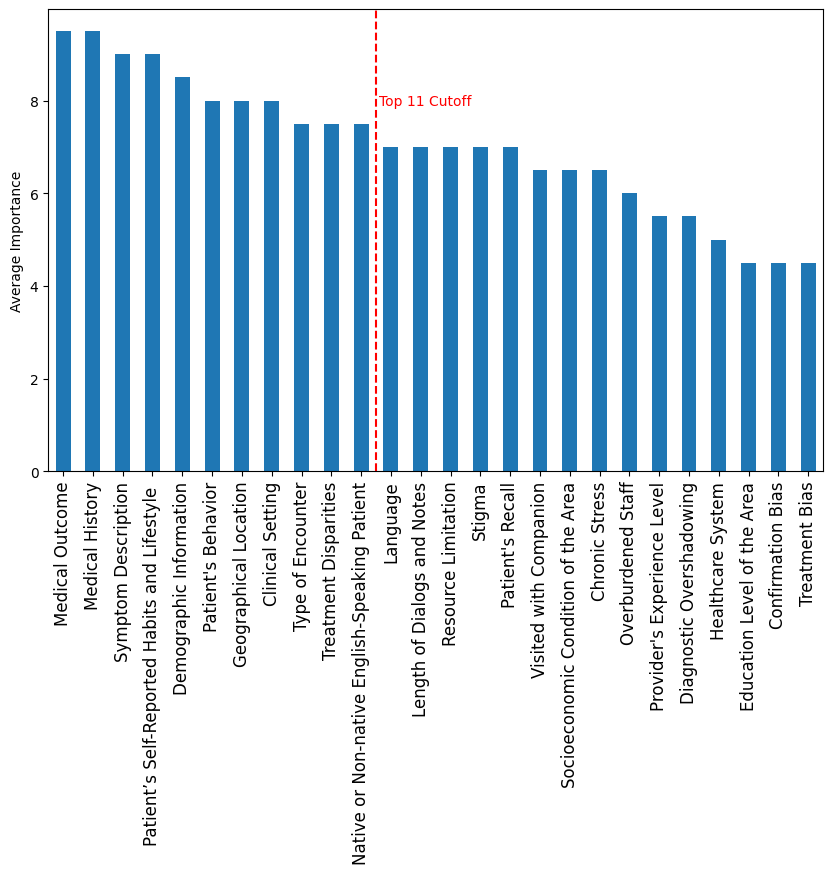

In [13]:

# Plotting the sorted values
ax = df_sorted.plot(kind='bar', legend=False, figsize=(10, 6))

# Setting the x-axis tick labels to be larger
ax.tick_params(axis='x', labelsize=12)  # Increase the labelsize to make the x-axis labels bigger

# Adding titles and labels
plt.ylabel('Average Importance')

line_position = 10.5
plt.axvline(x=line_position, color='red', linestyle='--')

# Add text to the red line
plt.text(line_position + 0.1, plt.ylim()[1] * 0.8, 'Top 11 Cutoff', color='red', verticalalignment='center')

# Show the plot
plt.show()

### sub-variables analysis:

In [44]:
def visualize(data, title=None, xlable="Sub_variable", ylable="Average Importance Score"):

    data_sorted = data.T.sort_values(by=data.index[0], ascending=False)    
    # Plotting the sorted values
    ax = data_sorted.plot(kind='bar', legend=False, figsize=(8, 4.5))

    # Adding titles and labels
    plt.title(title)
    plt.xlabel(xlable)
    plt.ylabel(ylable)


    line_position = 2.5
    plt.axvline(x=line_position, color='red', linestyle='--')
    

    # Show the plot
    plt.show()

In [48]:
# removing /n from the names:
df_average.columns = df_average.columns.str.replace('\n', '')

# replace space with underscoere:
df_average.columns = df_average.columns.str.replace(' ', '_')

df_average.columns

Index(['Name2', 'How_important_is_Demographic_Information?', 'Age', 'Gender',
       'Ethnicity', 'Socio-Economic_Status', 'Education_Level',
       'Health_Literacy', 'Job_Status', 'How_important_is_Medical_History?',
       'Previous_diagnoses', 'Family_medical_history', 'Medication_history',
       'Allergies', 'Chronic_conditions',
       'Please_let_us_know_any_suggestions/_comments/_feedback._They_might_include_any_sub-variable_that_you_think_is_important_and_missing,_or_anything_else.2',
       'How_important_is_Symptom_Description?', 'Severity', 'Duration',
       'Associated_Symptoms', 'Frequency', 'Impact_on_daily_activities',
       'Please_let_us_know_any_suggestions/_comments/_feedback._They_might_include_any_sub-variable_that_you_think_is_important_and_missing,_or_anything_else.3',
       'How_important_is_Clinical_Setting?',
       'Please_let_us_know_any_suggestions/_comments/_feedback._They_might_include_any_sub-variable_that_you_think_is_important_to_consider,_or_anyt

In [29]:
df_average['Family_medical_history']

2    7
Name: Family_medical_history, dtype: int64

In [30]:
df_average_medical_history = df_average[['Previous_diagnoses', 'Family_medical_history', 'Medication_history',
       'Allergies', 'Chronic_conditions']]
df_average_medical_history

,Previous_diagnoses,Family_medical_history,Medication_history,Allergies,Chronic_conditions
2,9,7,8.5,7.5,9


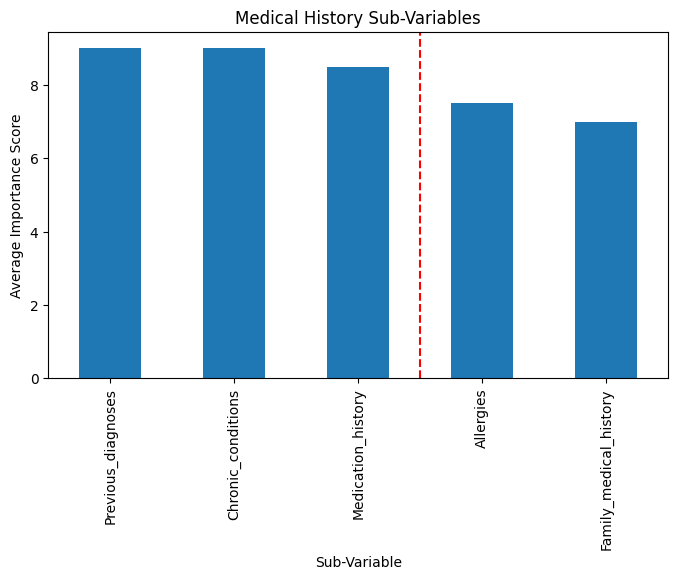

In [42]:
visualize(df_average_medical_history, "Medical History Sub-Variables", "Sub-Variable", "Average Importance Score")

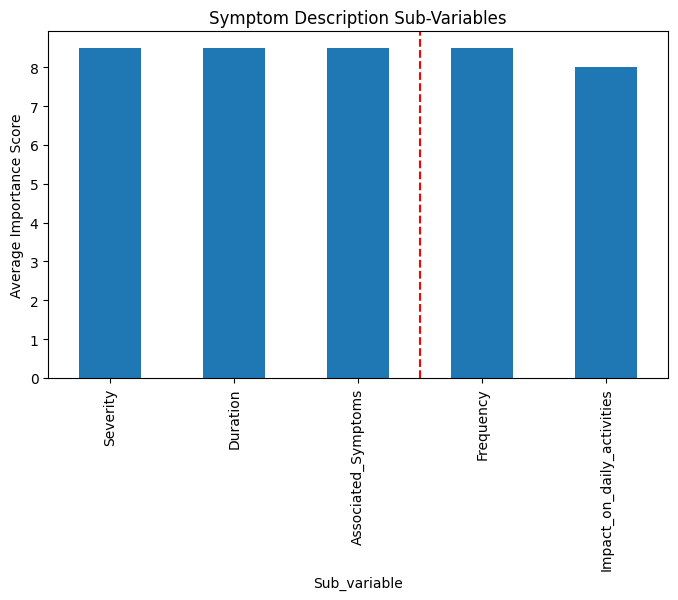

In [43]:
df_average_symptoms = df_average[['Severity', 'Duration',
       'Associated_Symptoms', 'Frequency', 'Impact_on_daily_activities']]

visualize(df_average_symptoms, "Symptom Description Sub-Variables", "Sub_variable", "Average Importance Score")

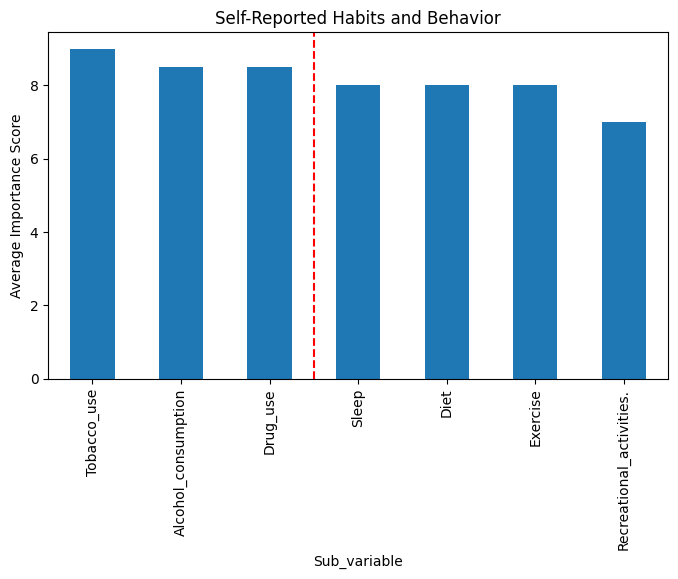

In [47]:
df_average_habits = df_average[["Sleep", "Diet", "Exercise", "Tobacco_use", "Alcohol_consumption", "Drug_use", "Recreational_activities."]]

visualize(df_average_habits, "Self-Reported Habits and Behavior")

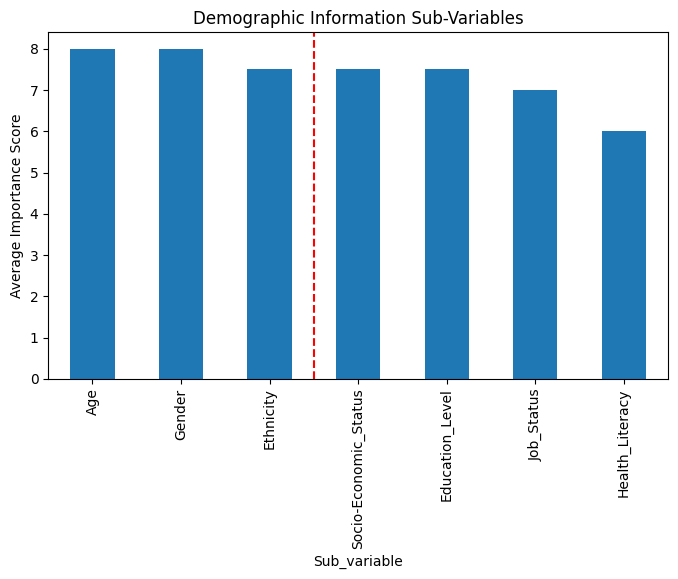

In [49]:
df_average_demographic = df_average[['Age', 'Gender',
       'Ethnicity', 'Socio-Economic_Status', 'Education_Level',
       'Health_Literacy', 'Job_Status']]
visualize(df_average_demographic, "Demographic Information Sub-Variables")

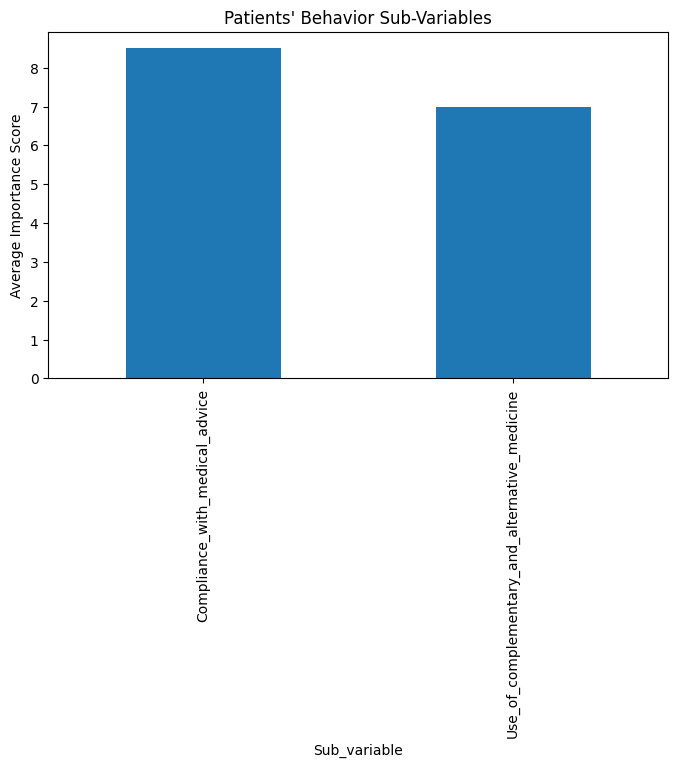

In [50]:
df_average_behavior = df_average[['Compliance_with_medical_advice',
       'Use_of_complementary_and_alternative_medicine']]
visualize(df_average_behavior, "Patients' Behavior Sub-Variables")

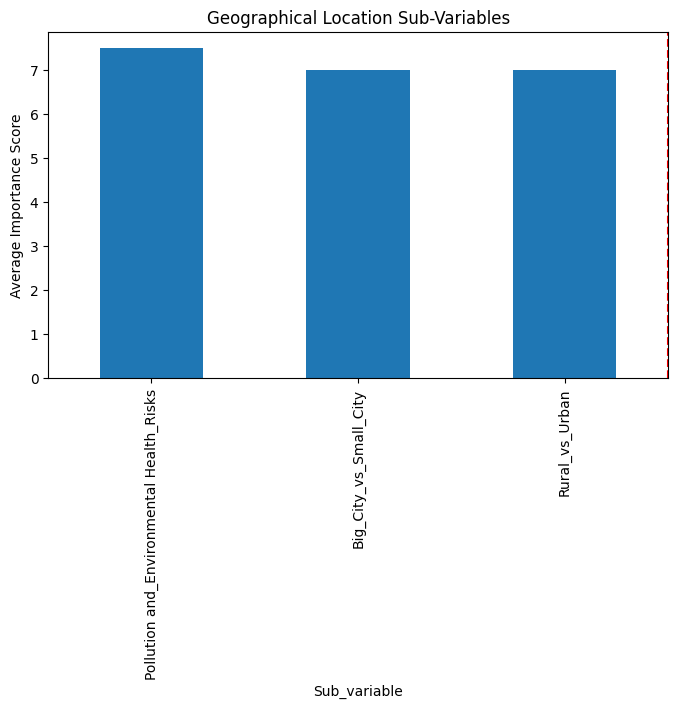

In [51]:
df_average_geographic = df_average[['Big_City_vs_Small_City',
       'Rural_vs_Urban', 'Pollution and_Environmental Health_Risks']]

visualize(df_average_geographic, "Geographical Location Sub-Variables")

## Interannotator agreement:

In [3]:
import pandas as pd
df = pd.read_excel("/Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/data/input/Potential Control Variables for Synthetic Doctor-Patient Dialog and Note Generation-Form 1.xlsx")
df.head()

,ID,Start time,Completion time,Email,Name,Last modified time,Name2,Professional Title2,How important is Demographic Information?,Age,...,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.15",How important is Diagnostic Overshadowing?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.16",How important is Chronic Stress?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.17",How important is Stigma?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.18",How important is Treatment Disparities?,"Please let us know any suggestions/ comments/ feedback. They might include any sub-variable that you think is important to consider, or anything else.19","Please let us know any comments or feedback, including any variables that you think is important and missing, suggestions for merging variables, or any other feedback you see fit. Thank you."
0,2.0,2023-12-05 21:17:43,2023-12-05 21:27:13,anonymous,NaN,NaN,Christopher Meaney,Biostatistician,8.0,8,...,NaN,5.0,NaN,7.0,NaN,7,NaN,7.0,NaN,NaN
1,3.0,2023-12-10 16:51:42,2023-12-10 17:05:59,anonymous,NaN,NaN,Noah Crampton,Family physician,9.0,8,...,NaN,6.0,NaN,6.0,NaN,7,NaN,8.0,NaN,Physical exam? Investigation/Test results? Ref...
2,NaN,NaT,NaT,NaN,NaN,NaN,avegare_score,NaN,8.5,8,...,0.0,5.5,0.0,6.5,0.0,7,0.0,7.5,0.0,NaN


In [4]:
# droping the NaN:
df = df.dropna(axis='columns')
df

,Name2,How important is Demographic Information?,Age,Gender,Ethnicity,Socio-Economic Status,Education Level,Health Literacy,Job Status,How important is Medical History?,...,How important is Patient's Recall?,How important is Confirmation Bias?,How important is Treatment Bias?,How important is Socioeconomic Condition of the Area?,How important is Resource Limitation?,How important is Overburdened Staff?,How important is Diagnostic Overshadowing?,How important is Chronic Stress?,How important is Stigma?,How important is Treatment Disparities?
0,Christopher Meaney,8.0,8,8,7.0,7.0,7.0,6,7,9.0,...,7,4.0,4.0,4.0,5,5,5.0,7.0,7,7.0
1,Noah Crampton,9.0,8,8,8.0,8.0,8.0,6,7,10.0,...,7,5.0,5.0,9.0,9,7,6.0,6.0,7,8.0
2,avegare_score,8.5,8,8,7.5,7.5,7.5,6,7,9.5,...,7,4.5,4.5,6.5,7,6,5.5,6.5,7,7.5


In [5]:
# just to focus on high-level variables for now, not sub variables:

df_subset = df[[col for col in df.columns if 'How important is' in col]]
df_subset.columns

Index(['How important is Demographic Information?',
       'How important is Medical History?',
       'How important is Symptom Description?',
       'How important is Clinical Setting?',
       'How important is Geographical Location?',
       'How important is Provider's Experience Level?',
       'How important is Type of Encounter?',
       'How important is Length of Dialogs and Notes?',
       'How important is Education Level of the Area?',
       'How important is Native or Non-native English-Speaking Patient?',
       'How important is Language?', 'How important is Medical Outcome?',
       'How important is Healthcare System?',
       'How important is Patient's Behavior?',
       'How important is Patient’s Self-Reported Habits and Lifestyle ?',
       'How important is Visited with Companion?',
       'How important is Patient's Recall?',
       'How important is Confirmation Bias?',
       'How important is Treatment Bias?',
       'How important is Socioeconomic Conditio

In [6]:
# cleaning the names:
df_subset.columns = [col.replace('How important is ', '').replace('?', '') for col in df_subset.columns]
df_subset.columns

Index(['Demographic Information', 'Medical History', 'Symptom Description',
       'Clinical Setting', 'Geographical Location',
       'Provider's Experience Level', 'Type of Encounter',
       'Length of Dialogs and Notes', 'Education Level of the Area',
       'Native or Non-native English-Speaking Patient', 'Language',
       'Medical Outcome', 'Healthcare System', 'Patient's Behavior',
       'Patient’s Self-Reported Habits and Lifestyle ',
       'Visited with Companion', 'Patient's Recall', 'Confirmation Bias',
       'Treatment Bias', 'Socioeconomic Condition of the Area',
       'Resource Limitation', 'Overburdened Staff', 'Diagnostic Overshadowing',
       'Chronic Stress', 'Stigma', 'Treatment Disparities'],
      dtype='object')

In [8]:
# only raw scores, not the averages:

df_subset= df_subset.head(2)
df_subset

,Demographic Information,Medical History,Symptom Description,Clinical Setting,Geographical Location,Provider's Experience Level,Type of Encounter,Length of Dialogs and Notes,Education Level of the Area,Native or Non-native English-Speaking Patient,...,Patient's Recall,Confirmation Bias,Treatment Bias,Socioeconomic Condition of the Area,Resource Limitation,Overburdened Staff,Diagnostic Overshadowing,Chronic Stress,Stigma,Treatment Disparities
0,8.0,9.0,8,9,8,6.0,6.0,5,4.0,8.0,...,7,4.0,4.0,4.0,5,5,5.0,7.0,7,7.0
1,9.0,10.0,10,7,8,5.0,9.0,9,5.0,7.0,...,7,5.0,5.0,9.0,9,7,6.0,6.0,7,8.0


In [22]:
# Transpose for easier ICC calculation (raters as rows, variables as columns)
df_t = df_subset.transpose()
df_t.columns = ["Rater1", "Rater2"]
df_t

,Rater1,Rater2
Demographic Information,8.0,9.0
Medical History,9.0,10.0
Symptom Description,8.0,10.0
Clinical Setting,9.0,7.0
Geographical Location,8.0,8.0
Provider's Experience Level,6.0,5.0
Type of Encounter,6.0,9.0
Length of Dialogs and Notes,5.0,9.0
Education Level of the Area,4.0,5.0
Native or Non-native English-Speaking Patient,8.0,7.0


In [ ]:
#! pip install --upgrade pingouin

In [29]:
import pandas as pd
from pingouin import intraclass_corr

data = {
    "Variable": [
        "Demographic Information", "Medical History", "Symptom Description",
        "Clinical Setting", "Geographical Location", "Provider's Experience Level",
        "Type of Encounter", "Length of Dialogs and Notes", "Education Level of the Area",
        "Native or Non-native English-Speaking Patient", "Language", "Medical Outcome",
        "Healthcare System", "Patient's Behavior", "Patient’s Self-Reported Habits and Lifestyle",
        "Visited with Companion", "Patient's Recall", "Confirmation Bias", "Treatment Bias",
        "Socioeconomic Condition of the Area", "Resource Limitation", "Overburdened Staff",
        "Diagnostic Overshadowing", "Chronic Stress", "Stigma", "Treatment Disparities"
    ],
    "Rater1": [
        8.0, 9.0, 8.0, 9.0, 8.0, 6.0, 6.0, 5.0, 4.0, 8.0,
        5.0, 9.0, 4.0, 8.0, 9.0, 5.0, 7.0, 4.0, 4.0, 4.0,
        5.0, 5.0, 5.0, 7.0, 7.0, 7.0
    ],
    "Rater2": [
        9.0, 10.0, 10.0, 7.0, 8.0, 5.0, 9.0, 9.0, 5.0, 7.0,
        9.0, 10.0, 6.0, 8.0, 9.0, 8.0, 7.0, 5.0, 5.0, 9.0,
        9.0, 7.0, 6.0, 6.0, 7.0, 8.0
    ]
}

df = pd.DataFrame(data)
print(df)


                                         Variable  Rater1  Rater2
0                         Demographic Information     8.0     9.0
1                                 Medical History     9.0    10.0
2                             Symptom Description     8.0    10.0
3                                Clinical Setting     9.0     7.0
4                           Geographical Location     8.0     8.0
5                     Provider's Experience Level     6.0     5.0
6                               Type of Encounter     6.0     9.0
7                     Length of Dialogs and Notes     5.0     9.0
8                     Education Level of the Area     4.0     5.0
9   Native or Non-native English-Speaking Patient     8.0     7.0
10                                       Language     5.0     9.0
11                                Medical Outcome     9.0    10.0
12                              Healthcare System     4.0     6.0
13                             Patient's Behavior     8.0     8.0
14   Patie

In [30]:
# Melt the data into long format required for ICC calculation
df_long = df.melt(id_vars=["Variable"], var_name="Rater", value_name="Score")

icc_results = intraclass_corr(
    data=df_long,
    targets="Variable",  # Variables being rated
    raters="Rater",      # Raters
    ratings="Score"      # Scores
)

print("Intra-Class Correlation (ICC) Results:")
print(icc_results[["Type", "ICC"]])


Intra-Class Correlation (ICC) Results:
    Type       ICC
0   ICC1  0.323550
1   ICC2  0.387204
2   ICC3  0.476970
3  ICC1k  0.488912
4  ICC2k  0.558251
5  ICC3k  0.645877


In [27]:
icc_results


,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.323550,1.956610,25,26,0.047576,"[-0.06, 0.63]"
1,ICC2,Single random raters,0.387204,2.823875,25,25,0.005942,"[0.01, 0.67]"
2,ICC3,Single fixed raters,0.476970,2.823875,25,25,0.005942,"[0.12, 0.73]"
3,ICC1k,Average raters absolute,0.488912,1.956610,25,26,0.047576,"[-0.13, 0.77]"
4,ICC2k,Average random raters,0.558251,2.823875,25,25,0.005942,"[0.01, 0.8]"
5,ICC3k,Average fixed raters,0.645877,2.823875,25,25,0.005942,"[0.21, 0.84]"


In [31]:
from scipy.stats import pearsonr, spearmanr

df = pd.DataFrame(data)

# Calculate Pearson correlation
pearson_corr, pearson_p = pearsonr(df["Rater1"], df["Rater2"])

# Calculate Spearman correlation
spearman_corr, spearman_p = spearmanr(df["Rater1"], df["Rater2"])

# Display results
print(f"Pearson Correlation: {pearson_corr:.3f} (p-value: {pearson_p:.3f})")
print(f"Spearman Correlation: {spearman_corr:.3f} (p-value: {spearman_p:.3f})")

Pearson Correlation: 0.479 (p-value: 0.013)
Spearman Correlation: 0.482 (p-value: 0.013)
